In [1]:
! pip install category_encoders


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<h1> Implementando regressão linear </h1>
<h4>Primeiro implementamos um loop que usa Kfold, feature encoding, treina um modelo de regressão linear e nos da as métricas </h4>
<h4>Depois, fazemos isso novamente, porém sem utilizar bibliotecas do sklearn </h4>
<h4>Em seguida, testamos outros modelos, como RandomForestRegressor e XGBoost e comparamos os resultados</h4> 

In [2]:
import pandas as pd 

In [3]:
df = pd.read_csv('./archive/Salary Data.csv')
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [4]:
nulos = df.isnull().sum()
nulos

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [5]:
df = df.dropna()
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [6]:
df['Job Title'].value_counts()


Job Title
Director of Marketing             12
Director of Operations            11
Senior Business Analyst           10
Senior Marketing Manager           9
Senior Marketing Analyst           9
                                  ..
Junior Social Media Specialist     1
Junior Operations Coordinator      1
Senior HR Specialist               1
Director of HR                     1
Junior Financial Advisor           1
Name: count, Length: 174, dtype: int64

<h5>Primeiro modelo </h5>

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def regression_report(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print("--- Regression Report ---")
    print(f"MAE:  R$ {mae:.2f}")
    print(f"MSE:  R$ {mse:.2f}")
    print(f"RMSE: R$ {rmse:.2f}")
    print(f"R²:   {r2:.4f}")
    print("-------------------------")

In [26]:
from category_encoders import TargetEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import StratifiedKFold
from category_encoders import TargetEncoder
from sklearn.metrics import mean_absolute_error

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
for train_index, val_index in skf.split(df, df['Salary']):
    # Divisão dos dados do Fold
    X_train, X_val = df.iloc[train_index].drop(['Salary'], axis=1), df.iloc[val_index].drop(['Salary'], axis=1)
    y_train, y_val = df.iloc[train_index]['Salary'], df.iloc[val_index]['Salary']

    # 1. Instanciar o encoder dentro do loop
    encoder = TargetEncoder(cols=[ 'Gender', 'Education Level', 'Job Title'], smoothing=10.0)

    # 2. Fit no treino e transform no treino e na validação
    X_train_encoded = encoder.fit_transform(X_train, y_train)
    X_val_encoded = encoder.transform(X_val)

    model = LinearRegression()
    model.fit(X_train_encoded, y_train)
    y_pred = model.predict(X_val_encoded)

    regression_report(y_val, y_pred)
    
    print(f"Processando Fold {fold}...")
    fold += 1

c:\Users\maria\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


--- Regression Report ---
MAE:  R$ 11589.64
MSE:  R$ 237549614.74
RMSE: R$ 15412.64
R²:   0.8793
-------------------------
Processando Fold 1...
--- Regression Report ---
MAE:  R$ 14289.24
MSE:  R$ 401337960.11
RMSE: R$ 20033.42
R²:   0.8220
-------------------------
Processando Fold 2...
--- Regression Report ---
MAE:  R$ 14989.45
MSE:  R$ 490714848.55
RMSE: R$ 22152.08
R²:   0.8092
-------------------------
Processando Fold 3...
--- Regression Report ---
MAE:  R$ 13987.08
MSE:  R$ 473890683.32
RMSE: R$ 21769.03
R²:   0.8212
-------------------------
Processando Fold 4...
--- Regression Report ---
MAE:  R$ 13388.02
MSE:  R$ 298453506.11
RMSE: R$ 17275.81
R²:   0.8612
-------------------------
Processando Fold 5...


In [9]:
regression_report(y_val, y_pred)

--- Regression Report ---
MAE:  R$ 17315.74
MSE:  R$ 556395788.01
RMSE: R$ 23588.04
R²:   0.7413
-------------------------


<h5> Segundo modelo</h5>

In [32]:
class targetEncoderNovo:
    def __init__(self, cols=None, m=10):
        self.cols = cols
        self.m = m
        self.target_means = {}
        self.global_mean = 0

    def fit(self, X, y):
        self.global_mean = y.values.mean()
        
        if self.cols is None:
            self.cols = X.columns.tolist()

        for col in self.cols:
            self.target_means[col] = {} 
            
            for cat in X[col].unique():
            
                mask = (X[col] == cat).values
                ncat = mask.sum()
                
                if ncat > 0:
                    mean_cat = y.values[mask].mean()
                    weight_cat = ncat / (self.m + ncat)
                    valor_encodado = (weight_cat * mean_cat) + ((1 - weight_cat) * self.global_mean)
                else:
                    valor_encodado = self.global_mean
                
                self.target_means[col][cat] = valor_encodado

    def transform(self, X):
        X_transformado = X.copy()
        for col in self.cols:
            X_transformado[col] = X_transformado[col].map(self.target_means[col])
            X_transformado[col] = X_transformado[col].fillna(self.global_mean)
        return X_transformado

    def fit_transform(self, X, y):
        self.fit(X, y)
        return self.transform(X)

In [20]:
class MeuStandardScaler:
    def __init__(self):
        self.medias = None
        self.desvios = None

    def fit(self, X):
        self.medias = X.mean()
        self.desvios = X.std()
        self.desvios = self.desvios.replace(0, 1)

    def transform(self, X):
        X_padronizado = (X - self.medias) / self.desvios
        return X_padronizado
        
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [12]:
class KfoldNovo:
    def __init__(self, k=5):
        self.k = k

    def _create_bins(self, y, bins=10):
        cut = np.percentile(y, np.linspace(0, 100, bins + 1))
        return np.digitize(y, cut, right=True)

    def split(self, X, y):
        y_binned = self._create_bins(y)
        folds_validacao = [[]for _ in range(self.k)]
        for val in np.unique(y_binned):
            indices = np.where(y_binned == val)[0]
            pedacos = np.array_split(indices, self.k)
            for i  in range(self.k):
                folds_validacao[i].extend(pedacos[i])
        for fold in range(self.k):
            indices_validacao = np.array(folds_validacao[fold])
            listas_de_treino = [folds_validacao[j] for j in range(self.k) if j != fold]
            indices_treino = np.concatenate(listas_de_treino)
            yield indices_treino, indices_validacao

In [ ]:
class MinhaRegressaoLinear:
    def __init__(self, learning_rate=0.001, epochs=1000, penalty=None, alpha=0.1, l1_ratio=0.5):
        self.beta = None
        self.bias = 0
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.penalty = penalty
        self.l1_ratio = l1_ratio
        self.alpha = alpha

    def predict (self, x_i):
        return np.dot(x_i, self.beta) + self.bias
    

    def gradiente_regularizacao(self):
        if self.penalty == 'l2':
            return 2 * self.alpha * self.beta
        elif self.penalty == 'l1':
            return self.alpha * np.sign(self.beta)
        elif self.penalty == 'elasticnet':
            l1_component = self.l1_ratio * np.sign(self.beta)
            l2_component = (1- self.l1_ratio) * self.beta
            return self.alpha * (l1_component + l2_component)
        else:
            return 0

    def fit(self, X, y):
        N, num_features = X.shape
        self.beta = np.zeros(num_features)
        self.bias = 0
        for _ in range(self.epochs):
            previsoes = self.predict(X)
            erro = (previsoes - y)
            gradiente_beta = (2/N) * np.dot(X.T, erro)
            gradiente_bias = (2/N) * np.sum(erro)

            gradiente_beta += self.gradiente_regularizacao()

            self.beta = self.beta - (self.learning_rate * gradiente_beta)
            self.bias = self.bias - (self.learning_rate * gradiente_bias)

In [18]:


def regression_report_calculado(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred)**2)
    rmse = np.sqrt(mse)
    
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - (ss_res / ss_tot)
    
    print("--- Regression Report ---")
    print(f"MAE:  R$ {mae:.2f}")
    print(f"MSE:  R$ {mse:.2f}")
    print(f"RMSE: R$ {rmse:.2f}")
    print(f"R²:   {r2:.4f}")
    print("-------------------------")

In [34]:
skf = KfoldNovo(k=5)

fold = 1
for train_index, val_index in skf.split(df, df['Salary']):
    X_train, X_val = df.iloc[train_index].drop(['Salary'], axis=1), df.iloc[val_index].drop(['Salary'], axis=1)
    y_train, y_val = df.iloc[train_index]['Salary'], df.iloc[val_index]['Salary']

    encoder = targetEncoderNovo(cols=['Gender', 'Education Level', 'Job Title'])
    scaler = MeuStandardScaler()


    X_train_encoded = encoder.fit_transform(X_train, y_train)
    X_val_encoded = encoder.transform(X_val)

    X_train_scaled = scaler.fit_transform(X_train_encoded)
    X_val_scaled = scaler.transform(X_val_encoded)
    X_treino_matriz = X_train_scaled.to_numpy()
    y_treino_vetor = (y_train).to_numpy()
    
    model = MinhaRegressaoLinear(learning_rate=0.1, epochs=5000)
    model.fit(X_treino_matriz, y_treino_vetor)
    
    print(f"\n--- Raio-X do Fold {fold} ---")
    print(f"Betas Aprendidos: {model.beta}")
    
    X_val_matriz = X_val_scaled.to_numpy()
    y_pred = model.predict(X_val_matriz )


    regression_report_calculado(y_val, y_pred)
    
    print(f"Processando Fold {fold}...")
    fold += 1


--- Raio-X do Fold 1 ---
Betas Aprendidos: [21231.47076391  3414.70674177  8885.14754157  8833.49074435
 10500.96972369]
--- Regression Report ---
MAE:  R$ 12496.69
MSE:  R$ 342045422.00
RMSE: R$ 18494.47
R²:   0.8701
-------------------------
Processando Fold 1...

--- Raio-X do Fold 2 ---
Betas Aprendidos: [23533.2410357   2991.27117515  5950.75998014  9092.0929219
 11377.51251551]
--- Regression Report ---
MAE:  R$ 14778.76
MSE:  R$ 419685788.42
RMSE: R$ 20486.23
R²:   0.8300
-------------------------
Processando Fold 2...

--- Raio-X do Fold 3 ---
Betas Aprendidos: [20808.45341217  3865.39643491  7878.07742719  9982.38888192
 12620.20458627]
--- Regression Report ---
MAE:  R$ 9738.66
MSE:  R$ 166185840.70
RMSE: R$ 12891.31
R²:   0.9205
-------------------------
Processando Fold 3...

--- Raio-X do Fold 4 ---
Betas Aprendidos: [21106.92271021  4645.3910163   8895.77866639 10374.30900194
 10704.89791572]
--- Regression Report ---
MAE:  R$ 9002.61
MSE:  R$ 137844997.06
RMSE: R$ 11740

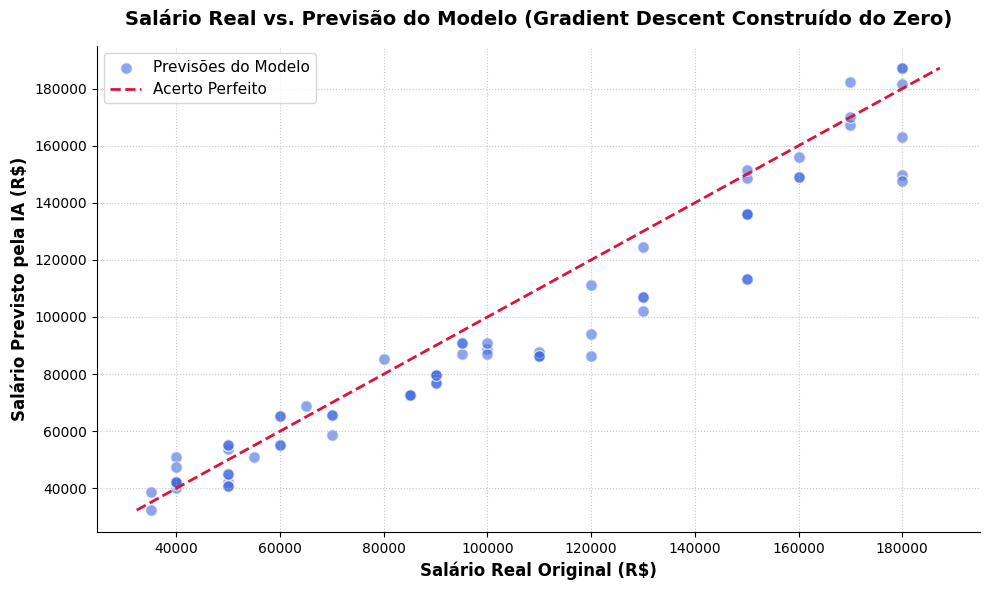

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Configurando o "quadro" (tamanho da imagem)
plt.figure(figsize=(10, 6))

# 2. Plotando as previsões do seu modelo (as bolinhas)
# O alpha=0.6 deixa as bolinhas meio transparentes, ótimo para ver onde elas se amontoam
plt.scatter(y_val, y_pred, alpha=0.6, color='royalblue', edgecolor='white', s=70, label='Previsões do Modelo')

# 3. Criando a "Linha Perfeita" (A reta de R² = 1.0)
# Achamos o menor e o maior valor para a reta cruzar o gráfico de ponta a ponta
limite_min = min(np.min(y_val), np.min(y_pred))
limite_max = max(np.max(y_val), np.max(y_pred))

plt.plot([limite_min, limite_max], [limite_min, limite_max], 
         color='crimson', linestyle='--', linewidth=2, label='Acerto Perfeito')

# 4. Deixando o gráfico com cara de relatório profissional
plt.title('Salário Real vs. Previsão do Modelo (Gradient Descent Construído do Zero)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Salário Real Original (R$)', fontsize=12, fontweight='bold')
plt.ylabel('Salário Previsto pela IA (R$)', fontsize=12, fontweight='bold')

# Adiciona a legenda e um fundo com grade suave para facilitar a leitura
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)

# Remove as bordas feias de cima e da direita
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# 5. Revela a obra de arte!
plt.tight_layout()
plt.show()

<h5>Treinando outros modelos e comparando resultados </h5>

In [ ]:
! pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 4.2 MB/s eta 0:00:24
   ---------------------------------------- 0.5/101.7 MB 4.2 MB/s eta 0:00:24
   ---------------------------------------- 1.0/101.7 MB 1.4 MB/s eta 0:01:12
    --------------------------------------- 1.8/101.7 MB 1.8 MB/s eta 0:00:56
    --------------------------------------- 2.4/101.7 MB 1.9 MB/s eta 0:00:52
   - -------------------------------------- 2.6/101.7 MB 1.8 MB/s eta 0:00:55
   - -------------------------------------- 3.1/101.7 MB 2.1 MB/s eta 0:00:49
   - -------------------------------------- 3.7/101.7 MB 2.1 MB/s eta 0:00:48
   - -------------------------------------- 3.7/101.7 MB 2.1 MB/s eta 0:00:48
   - -------------------------------------- 3.7/101.7 MB 2.1 MB/s eta 0:00:48
   - -------------------------------------- 3.7/101.7 MB 2.1 MB/s eta 0:00:48



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# 1. Preparação dos dados e Estratificação
# Criamos faixas de salário para garantir que cada fold tenha salários variados
df['salary_bins'] = pd.qcut(df['Salary'], q=5, labels=False)
X = df.drop(['Salary', 'salary_bins'], axis=1)
y = df['Salary']

# 2. Lista completa de modelos para o duelo
modelos_para_testar = [
    ('Linear Regression', LinearRegression()),
    ('Random Forest', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('XGBoost', XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)),
    ('SVR', SVR(kernel='rbf', C=1000, epsilon=0.1, gamma=0.1)),
    ('KNN', KNeighborsRegressor(n_neighbors=5))
]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Loop de Execução e Avaliação
print(f"{'Modelo':<20} | {'MAE':<12} | {'RMSE':<12} | {'R²':<10}")
print("-" * 65)

for nome, modelo in modelos_para_testar:
    mae_folds, rmse_folds, r2_folds = [], [], []
    
    for train_idx, val_idx in skf.split(df, df['salary_bins']):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # Pipeline Robust
        pipeline = Pipeline([
            ('encoder', TargetEncoder(cols=[ 'Gender', 'Education Level', 'Job Title'], smoothing=10.0)),
            ('scaler', StandardScaler()),
            ('regressor', modelo)
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_val)

        mae_folds.append(mean_absolute_error(y_val, y_pred))
        rmse_folds.append(np.sqrt(mean_squared_error(y_val, y_pred)))
        r2_folds.append(r2_score(y_val, y_pred))

    # Printando os resultados de forma organizada
    print(f"{nome:<20} | R$ {np.mean(mae_folds):>9.2f} | R$ {np.mean(rmse_folds):>9.2f} | {np.mean(r2_folds):>8.4f}")

Modelo               | MAE          | RMSE         | R²        
-----------------------------------------------------------------
Linear Regression    | R$  13076.90 | R$  18329.05 |   0.8535
Random Forest        | R$  17713.46 | R$  27729.07 |   0.6653
XGBoost              | R$  17812.57 | R$  28281.75 |   0.6516
SVR                  | R$  16087.95 | R$  21042.49 |   0.8078
KNN                  | R$  11357.68 | R$  16889.97 |   0.8747


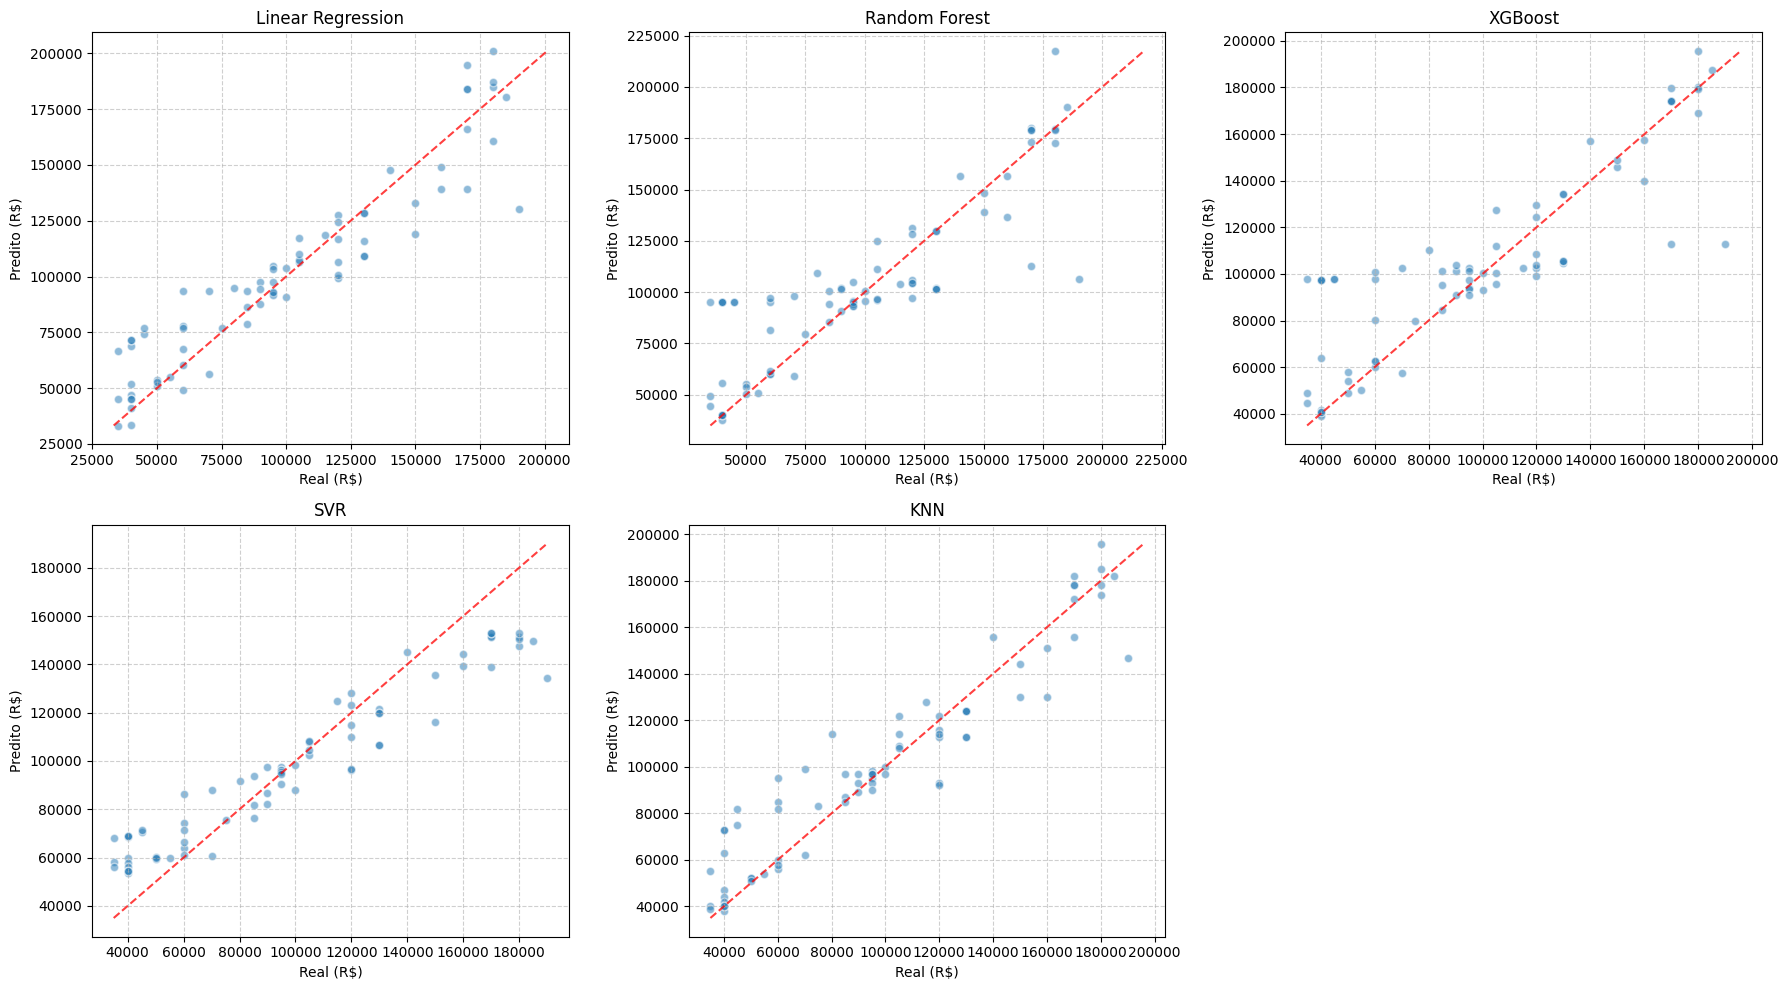

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando a figura para os 5 modelos (2 linhas, 3 colunas)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (nome, modelo) in enumerate(modelos_para_testar):
    # Usando um split simples para o gráfico (apenas para visualização rápida)
    pipeline = Pipeline([
        ('encoder', TargetEncoder(cols=[ 'Gender', 'Education Level', 'Job Title'], smoothing=10.0)),
        ('scaler', StandardScaler()),
        ('regressor', modelo)
    ])
    
    # Treinando no treino e predizendo na validação do último fold
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    
    # Plotando no subplot correspondente
    ax = axes[i]
    ax.scatter(y_val, y_pred, alpha=0.5, edgecolors='w')
    
    # Linha diagonal de 45 graus (Onde o modelo acertaria 100%)
    lims = [np.min([y_val.min(), y_pred.min()]), np.max([y_val.max(), y_pred.max()])]
    ax.plot(lims, lims, 'r--', alpha=0.75, zorder=3)
    
    ax.set_title(f'{nome}')
    ax.set_xlabel('Real (R$)')
    ax.set_ylabel('Predito (R$)')
    ax.grid(True, linestyle='--', alpha=0.6)

# Remove o último subplot vazio (já que temos 5 modelos e 6 espaços)
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()